# DEC extant species

## Loading data

In [1]:
library("ape")
library("optimx")
library("GenSA")
library("rexpokit")
library("cladoRcpp")
library("snow") 
library("parallel")
library("BioGeoBEARS")
library("palaeoverse")


Attachement du package : ‘parallel’


Les objets suivants sont masqués depuis ‘package:snow’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, clusterSplit, makeCluster, parApply,
    parCapply, parLapply, parRapply, parSapply, splitIndices,
    stopCluster




### Loading Tree

In [2]:
phy = "Input/Orectolobiformes_extant_tree.nex"

### Plotting Tree

In [3]:
tr = read.nexus(phy)
tr = ladderize(tr)

In [4]:
pdf("tree_orectolobiformes.pdf", width = 20, height = 10)
plot(tr, font = 3, cex = 0.75, label.offset = 1.5)
title("Orectolobiformes tree")
axis_geo(intervals = list("epochs", "periods"), phylo = TRUE, skip = c("Holocene", "Late Pleistocene"),height = 0.035, abbr = FALSE)
dev.off()

png 
  2

In [5]:
phy = "Input/tree_orecto.tree"

### Loading presence-absence matrix

In [6]:
table_geo = "Input/table_geo.txt"

### Loading time period file

In [7]:
time_period= "Input/time_period.txt"

### Loading connectivity matrix

In [8]:
connectivity_matrix = "Input/Transition_matrix.txt"

## Setting up DEC

### Intitialize DEC model

In [9]:
DEC_orectolobiformes = define_BioGeoBEARS_run()

### Setting up DEC input data

#### Phylogeny

In [10]:
DEC_orectolobiformes$trfn = phy

#### Presence-absence matrix

In [11]:
DEC_orectolobiformes$geogfn = table_geo

#### Tip range

In [12]:
tipranges = getranges_from_LagrangePHYLIP(lgdata_fn=table_geo)

#### Maximum range size

In [13]:
max_range_size = 5
DEC_orectolobiformes$max_range_size = max_range_size

#### State list

In [14]:
areas = getareas_from_tipranges_object(tipranges)
states_area_list = rcpp_areas_list_to_states_list(areas=areas, maxareas=max_range_size, include_null_range=TRUE)
DEC_orectolobiformes$states_list = states_area_list

#### Time periods

In [15]:
DEC_orectolobiformes$timesfn = time_period

In [16]:
DEC_orectolobiformes$timeperiods = unlist((unname(c(read.table(time_period)))))

#### Connectivity matrix

In [17]:
DEC_orectolobiformes$areas_adjacency_fn = connectivity_matrix

#### Forced nodes

In [18]:
#DEC_orectolobiformes$fixnode = c(43,63,64,75)
#DEC_orectolobiformes$fixlikes = matrix(c(0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,1,0,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,1,1,1,0,0,1,0,1,1,0,1,1,1,0,1,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,1,0,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,1,1,1,0,0,1,0,1,1,0,1,1,1,0,1,1,1,1,0,1,1,1,1,1,0,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1),ncol=63,nrow=4,byrow=TRUE)

#### Optimization parameters

In [19]:
DEC_orectolobiformes$force_sparse = FALSE
DEC_orectolobiformes$on_NaN_error = -1e50
DEC_orectolobiformes$speedup = FALSE        
DEC_orectolobiformes$use_optimx = TRUE    
DEC_orectolobiformes$num_cores_to_use = 24

#### Dividing the tree per time periods

In [20]:
DEC_orectolobiformes$return_condlikes_table = TRUE
DEC_orectolobiformes$calc_TTL_loglike_from_condlikes_table = TRUE
DEC_orectolobiformes$calc_ancprobs = TRUE

In [21]:
section_the_tree(inputs=DEC_orectolobiformes, make_master_table=TRUE, plot_pieces=FALSE, fossils_older_than=0.001, cut_fossils=FALSE)


1- top: 0, bot: 1, rel_bot: 1

2- top: 1, bot: 5, rel_bot: 4

3- top: 5, bot: 20, rel_bot: 15

4- top: 20, bot: 40, rel_bot: 20

5- top: 40, bot: 60, rel_bot: 20

6- top: 60, bot: 80, rel_bot: 20

7- top: 80, bot: 100, rel_bot: 20

8- top: 100, bot: 120, rel_bot: 20

9- top: 120, bot: 140, rel_bot: 20

10- top: 140, bot: 160, rel_bot: 20

11- top: 160, bot: 180, rel_bot: 20

12- top: 180, bot: 200, rel_bot: 20

13- top: 200, bot: 220, rel_bot: 20

14- top: 220, bot: 240, rel_bot: 20

15- top: 240, bot: 260, rel_bot: 20


$geogfn
[1] "Input/table_geo.txt"

$trfn
[1] "Input/tree_orecto.tree"

$abbr
[1] "default"

$description
[1] "defaults"

$BioGeoBEARS_model_object
An object of class "BioGeoBEARS_model"
Slot "params_table":
         type    init      min      max     est                note
d        free 0.01000  1.0e-12  5.00000 0.01000               works
e        free 0.01000  1.0e-12  5.00000 0.01000               works
a       fixed 0.00000  1.0e-12  5.00000 0.00000               works
b       fixed 1.00000  1.0e-12  1.00000 1.00000 non-stratified only
x       fixed 0.00000 -2.5e+00  2.50000 0.00000               works
n       fixed 0.00000 -1.0e+01 10.00000 0.00000               works
w       fixed 1.00000 -1.0e+01 10.00000 1.00000               works
u       fixed 0.00000 -1.0e+01 10.00000 0.00000               works
j       fixed 0.00000  1.0e-05  2.99999 0.00000               works
ysv       3-j 2.99999  1.0e-05  3.00000 2.99999               works
ys    ysv*2/3 1.99999  1.0e-05  2.00000 1.999

In [24]:
DEC_orectolobiformes = section_the_tree(inputs=DEC_orectolobiformes, make_master_table=TRUE, plot_pieces=FALSE, fossils_older_than=0.001, cut_fossils=FALSE)


1- top: 0, bot: 1, rel_bot: 1

2- top: 1, bot: 5, rel_bot: 4

3- top: 5, bot: 20, rel_bot: 15

4- top: 20, bot: 40, rel_bot: 20

5- top: 40, bot: 60, rel_bot: 20

6- top: 60, bot: 80, rel_bot: 20

7- top: 80, bot: 100, rel_bot: 20

8- top: 100, bot: 120, rel_bot: 20

9- top: 120, bot: 140, rel_bot: 20

10- top: 140, bot: 160, rel_bot: 20

11- top: 160, bot: 180, rel_bot: 20

12- top: 180, bot: 200, rel_bot: 20

13- top: 200, bot: 220, rel_bot: 20

14- top: 220, bot: 240, rel_bot: 20

15- top: 240, bot: 260, rel_bot: 20


#### Ancestral state estimation

#### Finalize settings

In [27]:
DEC_orectolobiformes = readfiles_BioGeoBEARS_run(DEC_orectolobiformes)

### Check inputs

In [28]:
check_BioGeoBEARS_run(DEC_orectolobiformes)

[1] TRUE

## Running the DEC analysis

In [29]:
runslow = TRUE
run_results = "Orecto_DEC.Rdata"
if (runslow){
    res = bears_optim_run(DEC_orectolobiformes)
    res    
    save(res, file=run_results)
    resDEC = res
} else {
    # Loads to "res"
    load(run_results)
    resDEC = res
}


bears_optim_run() note: overall states_list has 63 states/ranges. In stratum #1 (0-1 mya), states_list_for_this_stratum has 63 states/ranges, due to areas_allowed and/or areas_adjacency matrices. See BioGeoBEARS_run_object$lists_of_states_lists_0based.
bears_optim_run() note: overall states_list has 63 states/ranges. In stratum #2 (1-5 mya), states_list_for_this_stratum has 63 states/ranges, due to areas_allowed and/or areas_adjacency matrices. See BioGeoBEARS_run_object$lists_of_states_lists_0based.
bears_optim_run() note: overall states_list has 63 states/ranges. In stratum #3 (5-20 mya), states_list_for_this_stratum has 63 states/ranges, due to areas_allowed and/or areas_adjacency matrices. See BioGeoBEARS_run_object$lists_of_states_lists_0based.
bears_optim_run() note: overall states_list has 63 states/ranges. In stratum #4 (20-40 mya), states_list_for_this_stratum has 63 states/ranges, due to areas_allowed and/or areas_adjacency matrices. See BioGeoBEARS_run_object$lists_of_state

## Plotting Ancestral state estimates

In [40]:
results_object$inputs

$geogfn
[1] "Input/table_geo.txt"

$trfn
[1] "Input/tree_orecto.tree"

$abbr
[1] "default"

$description
[1] "defaults"

$BioGeoBEARS_model_object
An object of class "BioGeoBEARS_model"
Slot "params_table":
         type       init      min      max        est                note
d        free 0.02710470  1.0e-12  5.00000 0.02710470               works
e        free 0.01018441  1.0e-12  5.00000 0.01018441               works
a       fixed 0.00000000  1.0e-12  5.00000 0.00000000               works
b       fixed 1.00000000  1.0e-12  1.00000 1.00000000 non-stratified only
x       fixed 0.00000000 -2.5e+00  2.50000 0.00000000               works
n       fixed 0.00000000 -1.0e+01 10.00000 0.00000000               works
w       fixed 1.00000000 -1.0e+01 10.00000 1.00000000               works
u       fixed 0.00000000 -1.0e+01 10.00000 0.00000000               works
j       fixed 0.00000000  1.0e-05  2.99999 0.00000000               works
ysv       3-j 2.99999000  1.0e-05  3.00000 3.00000000

In [58]:
resDEC

$final_all_condlikes_of_each_state
      [,1]         [,2]         [,3]         [,4]         [,5]         [,6]
 [1,]    0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00
 [2,]    0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00
 [3,]    0 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00
 [4,]    0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [5,]    0 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00
 [6,]    0 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00 0.000000e+00
 [7,]    0 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00 0.000000e+00
 [8,]    0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [9,]    0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
[10,]    0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
[11,]    0 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00
[12,]    0 0.000000e+00 0.000000e+00 0.000000e+00 0.0

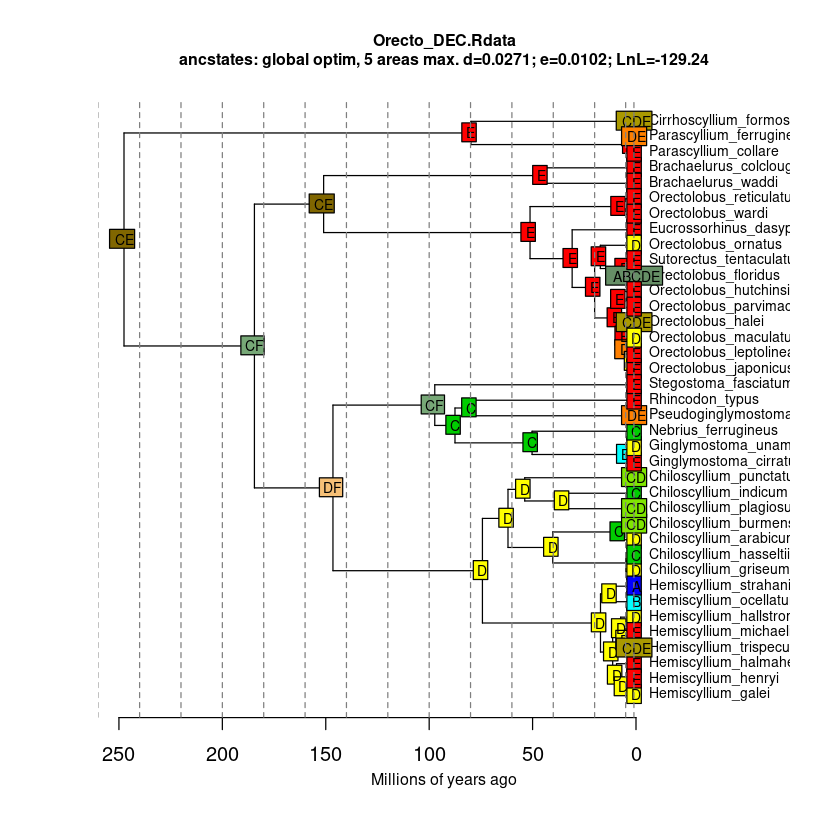

,LnL,nparams,d,e,j
,<list>,<list>,<list>,<list>,<list>
1,-129.2415,2,0.0271047,0.01018441,0


pdf 
  3

Warning message in system(cmdstr):
“erreur lors de l'exécution d'une commande”


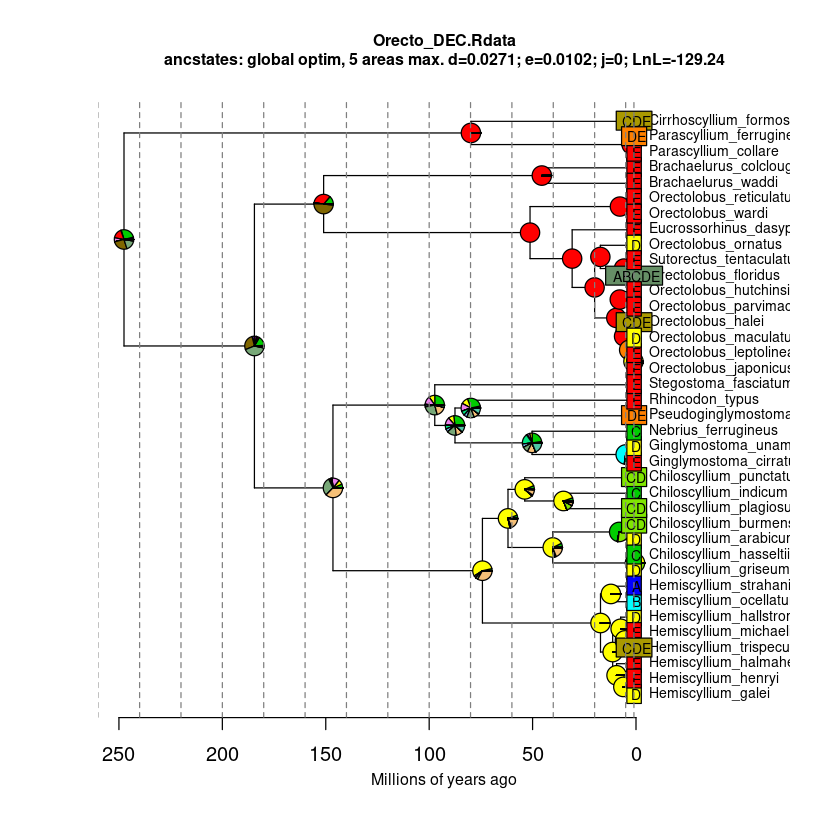

In [38]:
graphical_output = "Orecto_DEC.Rdata"

pdffn = "Orecto"

# Setup
results_object = resDEC
scriptdir = np(system.file("extdata/a_scripts", package="BioGeoBEARS"))

# States
res2 = plot_BioGeoBEARS_results(results_object, graphical_output,  plotwhat="text", label.offset=0.45, tipcex=0.7, statecex=0.7, splitcex=0.6, titlecex=0.8, plotsplits=FALSE, cornercoords_loc=scriptdir, include_null_range=TRUE, tr=tr, tipranges=tipranges)


# Pie chart

plot_BioGeoBEARS_results(results_object, graphical_output, addl_params=list("j"), plotwhat="pie", label.offset=0.45, tipcex=0.7, statecex=0.7, splitcex=0.6, titlecex=0.8, plotsplits=FALSE, cornercoords_loc=scriptdir, include_null_range=TRUE, tr=tr, tipranges=tipranges)


dev.off()  # Turn off PDF

cmdstr = paste("open ", pdffn, sep="")
system(cmdstr) # Plot it

In [103]:
prepare_df_plot <- function(data_bgb){
     data_plot_0 <- data.frame(matrix(nrow = nrow(data_bgb$relative_probs_of_each_state_at_branch_bottom_below_node_UPPASS),
                                ncol = 8))
      colnames(data_plot_0) <- c("end_state_1", "end_state_2", "end_state_3", 
                              "end_state_1_pp", "end_state_2_pp", "end_state_3_pp", 
                              "end_state_other_pp", "node")

    for (i in 1:nrow(data_bgb$ML_marginal_prob_each_state_at_branch_top_AT_node)) {
        row <- data_bgb$ML_marginal_prob_each_state_at_branch_top_AT_node[i,]
        data_plot_0[i, 1] <- order(row,decreasing=T)[1]
        data_plot_0[i, 2] <- order(row,decreasing=T)[2]
        data_plot_0[i, 3] <- order(row,decreasing=T)[3]
        data_plot_0[i, 4] <- row[order(row,decreasing=T)[1]]
        data_plot_0[i, 5] <- row[order(row,decreasing=T)[2]]
        data_plot_0[i, 6] <- row[order(row,decreasing=T)[3]]
        data_plot_0[i, 7] <- sum(row[order(row,decreasing=T)[4:length(row)]]) 
        data_plot_0[i, 8] <- i
    }
    
    states_plot <- sort(unique(c(data_plot_0$end_state_1,data_plot_0$end_state_2, data_plot_0$end_state_3)))
    full_data <- c()
    for( i in 1:nrow(data_plot_0)){
        temp_row <- rep(0, length(states_plot))
        temp_row[which(states_plot == data_plot_0[i,1])] <- data_plot_0[i, 4]
        temp_row[which(states_plot == data_plot_0[i,2])] <- data_plot_0[i, 5]
        temp_row[which(states_plot == data_plot_0[i,3])] <- data_plot_0[i, 6]
        temp_row[1] <- temp_row[1] + data_plot_0[i, 7]
        full_data <- rbind(full_data, temp_row)
    }
    full_data <- as.data.frame(cbind(full_data, data_plot_0$node))
    colnames(full_data) <- c(as.character(states_plot), "node")
    rownames(full_data) <- data_plot_0$node
return(full_data)
}

In [104]:
saveRDS(prepare_df_plot(resDEC), "ancestral_state.rds")